# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Penjelasan Dataset: California Housing Prices**

Dataset yang digunakan dalam eksperimen ini adalah **California Housing Prices** yang bersumber dari repositori publik Kaggle (https://www.kaggle.com/datasets/camnugent/california-housing-prices).

Dataset ini didasarkan pada data sensus California tahun 1990 dan sering digunakan sebagai standar untuk eksperimen regresi dalam *machine learning*. Data ini berisi informasi mengenai demografi, lokasi, dan kondisi perumahan di berbagai distrik (blok) di California.

**Karakteristik Data:**
* **Jumlah Fitur (X):** 9 fitur yang terdiri dari 8 fitur numerik (seperti `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`) dan 1 fitur kategorikal (`ocean_proximity`).
* **Target Variabel (y):** `median_house_value` (Harga median rumah di distrik tersebut, direpresentasikan dalam bentuk numerik / regresi).
* **Kondisi Data:** Terdapat beberapa *missing values* pada kolom `total_bedrooms` yang akan ditangani pada tahap *preprocessing* (menggunakan imputasi median).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# Library untuk Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Mengatur tampilan visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d camnugent/california-housing-prices
!unzip california-housing-prices.zip

# Memuat dataset (pastikan file housing.csv berada di directory yang sama)
file_path = 'housing.csv'
df = pd.read_csv(file_path)

# Melihat 5 baris pertama untuk memastikan data termuat
display(df.head())

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0
100% 400k/400k [00:00<00:00, 141MB/s]

Archive:  california-housing-prices.zip
  inflating: housing.csv             


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

--- Statistik Deskriptif ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


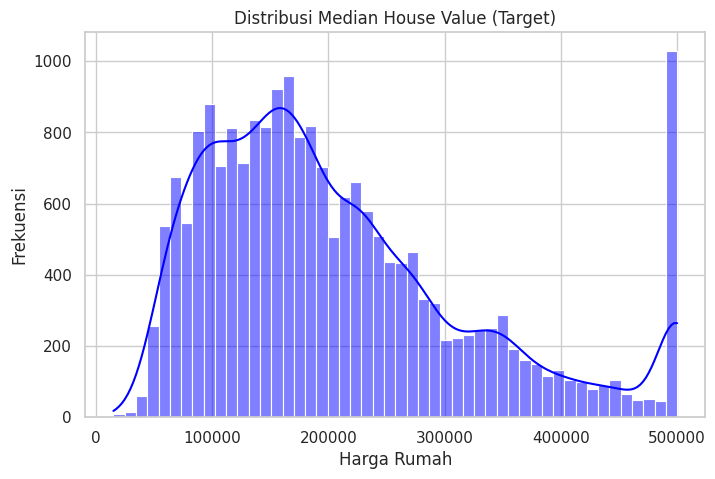

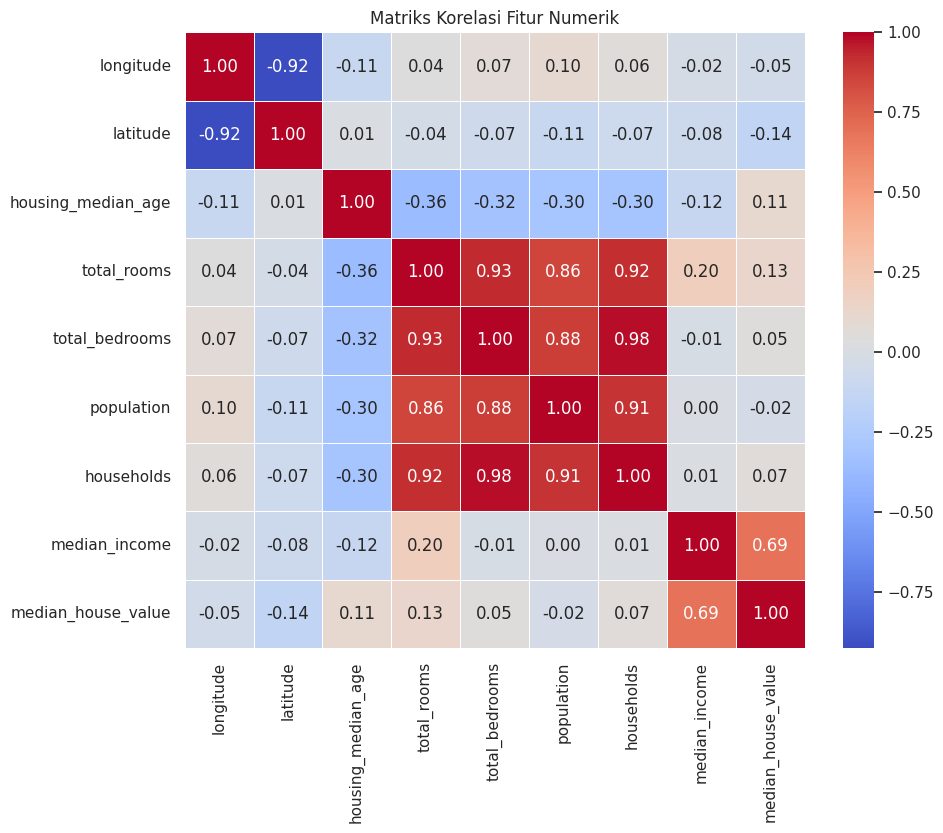

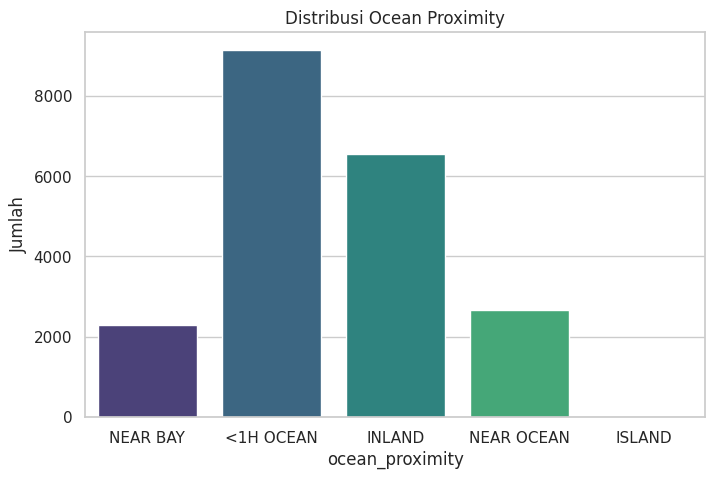

In [ ]:
print("--- Informasi Dataset ---")
df.info()
print("\n--- Statistik Deskriptif ---")
display(df.describe())

# 1. Distribusi Target (Harga Rumah)
plt.figure(figsize=(8, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='blue')
plt.title('Distribusi Median House Value (Target)')
plt.xlabel('Harga Rumah')
plt.ylabel('Frekuensi')
plt.show()

# 2. Korelasi Antar Fitur Numerik
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

# 3. Distribusi Data Kategorikal (Ocean Proximity)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ocean_proximity', palette='viridis')
plt.title('Distribusi Ocean Proximity')
plt.ylabel('Jumlah')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
target_col = 'median_house_value'
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ['ocean_proximity']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Dimensi X_train sebelum preprocessing: {X_train.shape}")
print(f"Dimensi X_train setelah preprocessing: {X_train_processed.shape}")
print(f"Dimensi X_test setelah preprocessing: {X_test_processed.shape}")

output_dir = 'california_preprocessing'
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, 'X_train.npy'), X_train_processed)
np.save(os.path.join(output_dir, 'X_test.npy'), X_test_processed)
np.save(os.path.join(output_dir, 'y_train.npy'), y_train.to_numpy())
np.save(os.path.join(output_dir, 'y_test.npy'), y_test.to_numpy())
joblib.dump(preprocessor, os.path.join(output_dir, 'preprocessor.pkl'))

print(f"\nData siap latih dan model preprocessor berhasil disimpan di folder '{output_dir}/'")

Dimensi X_train sebelum preprocessing: (16512, 9)
Dimensi X_train setelah preprocessing: (16512, 13)
Dimensi X_test setelah preprocessing: (4128, 13)

Data siap latih dan model preprocessor berhasil disimpan di folder 'california_preprocessing/'


In [ ]:
import shutil
from google.colab import files

# Nama folder yang ingin di-zip (sesuai dengan output sebelumnya)
folder_to_zip = 'california_preprocessing'
zip_filename = 'california_preprocessing_Pazrin.zip'

# Mengompres folder menjadi .zip
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', folder_to_zip)

print(f"Folder '{folder_to_zip}' berhasil dikompres menjadi '{zip_filename}'")

# Mengunduh file zip secara otomatis ke komputer Anda
files.download(zip_filename)

Folder 'california_preprocessing' berhasil dikompres menjadi 'california_preprocessing_Pazrin.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>